In [1]:
#reset không gian làm việc
!rm -rf /content/*


'rm' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# Tải toàn bộ kho lưu trữ
!git clone https://github.com/congnghia0609/ntc-scv.git

fatal: destination path 'ntc-scv' already exists and is not an empty directory.


In [3]:
!pip install keras tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import glob
import zipfile

# Giải nén dữ liệu từ file zip
def unzip_data(zip_file, extract_to):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Giải nén file zip dữ liệu huấn luyện và kiểm tra
unzip_data('ntc-scv/data/data_train.zip', 'ntc-scv/data/data_train')
unzip_data('ntc-scv/data/data_test.zip', 'ntc-scv/data/data_test')


In [6]:
# Cài đặt thư viện
!pip install pyvi
!pip install underthesea
!pip install nltk

import string
from underthesea import word_tokenize, pos_tag
from pyvi import ViTokenizer
import nltk
import re



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\NguyenXuanHoa\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\NguyenXuanHoa\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\NguyenXuanHoa\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip
c:\Users\NguyenXuanHoa\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [7]:
# Set the data paths
train_dir = 'ntc-scv/data/data_train/data_train/train'
train_add_dir = 'ntc-scv/data/data_train/data_train/test'
test_dir = 'ntc-scv/data/data_test/data_test/test'
from pyvi import ViTokenizer
import os

# Hàm tải dữ liệu từ thư mục
def load_data_from_dir_pyvi(directory):
    texts = []
    labels = []

    for label_type in ['neg', 'pos']:
        dir_name = os.path.join(directory, label_type)
        for fname in os.listdir(dir_name):
            if fname.endswith('.txt'):
                with open(os.path.join(dir_name, fname), encoding='utf-8') as f:
                    text = f.read()
                    texts.append(text)
                if label_type == 'neg':
                    labels.append(0)
                else:
                    labels.append(1)
    return texts, labels

# Tải dữ liệu train và test
train_texts, train_labels = load_data_from_dir_pyvi(train_dir)
train_add_texts, train_add_labels = load_data_from_dir_pyvi(train_add_dir)
test_texts, test_labels = load_data_from_dir_pyvi(test_dir)
train_texts.extend(train_add_texts)
train_labels.extend(train_add_labels)
print(train_texts[0])
train_labels[0]


Mua có mỗi Bingsu thập_cẩm 45k mà mình f đợi hơn 20 ' . Hỏi lại thì nv tl có r nhg bảo chờ thêm 15 ' nữa " tụi e lm liền " .
Mình k biết có ngon k nhg cũng muốn ăn thử . Thiết_nghĩ nv quán nên xem_lại cách pv và nc vs khách .



0

In [8]:
print(len(train_texts))
print(len(test_texts))
#

40000
10000


In [9]:
def xoa_dau_va_ki_tu_dac_biet(text):

    text = re.sub(r'https?://\S+|www\.\S+', '', text) # removing URL links
    text = re.sub(r"\b\d+\b", "", text) # removing number
    text = re.sub('<.*?>+', '', text) # removing special characters,
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) # punctuations
    text = re.sub('\n', '', text)
    text = re.sub('[\u2018\u2019\u201c\u201d\u2026]', '', text)

    return text
# Hàm loại bỏ dấu câu
def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

def to_lower(text):
    text = text.lower()
    return text

# Hàm loại bỏ danh từ và đại từ
def remove_nouns_pronouns(text):
    # Tách từ và gán nhãn từ loại
    tagged_words = pos_tag(text)
    # Loại bỏ các từ là danh từ (N) hoặc đại từ (P)
    filtered_words = [word for word, pos in tagged_words if pos not in ['N', 'P']]
    return ' '.join(filtered_words)

import urllib.request

# Tải stopwords từ Vietnamese Stopwords dataset
stopwords_url = 'https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt'
with urllib.request.urlopen(stopwords_url) as response:
    stopwords = set(line.decode('utf-8').strip() for line in response if line.strip())

def clean_text(text):
    text = xoa_dau_va_ki_tu_dac_biet(text)
    text = to_lower(text)
    remove_punctuation(text)
    # Loại bỏ stopwords
    words = text.split()
    words = [word for word in words if word not in stopwords]
    # Loại bỏ danh từ và đại từ
    text = ' '.join(words)
    text = remove_nouns_pronouns(text)

    # Tách từ tiếng Việt
    text = ViTokenizer.tokenize(text)
    return text


In [10]:
train_texts = [clean_text(text) for text in train_texts]
test_texts = [clean_text(text) for text in test_texts]
train_texts[0]

'mua 45 đợi tl nhg bảo chờ tụi e lm liền k thử nv pv vs'

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle
# Thông số cho mô hình
vocab_size = 20000   # Số lượng từ vựng tối đa trong từ điển. 
                     # Giảm số lượng từ giúp giảm kích thước mô hình và tiết kiệm tài nguyên tính toán,
                     # nhưng vẫn đủ để giữ lại các từ quan trọng nhất.

max_length = 300     # Độ dài tối đa của mỗi câu đầu vào. Các câu ngắn hơn sẽ được padding, 
                     # còn câu dài hơn sẽ được cắt ngắn. Độ dài này giúp cân bằng giữa độ chi tiết
                     # và hiệu quả tính toán.

embedding_dim = 128  # Kích thước vector embedding.

# Tokenizer cho văn bản
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_texts)

# Đường dẫn để lưu tokenizer
tokenizer_path = 'tokenizer.pkl'

# Lưu tokenizer vào file
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
word_index = tokenizer.word_index




In [11]:
word_index

{'<OOV>': 1,
 'ngon': 2,
 'đi': 3,
 '́': 4,
 '̀': 5,
 'uống': 6,
 'lắm': 7,
 'hơi': 8,
 'gọi': 9,
 'ko': 10,
 'i': 11,
 'mấy': 12,
 'nhânviên': 13,
 '̣': 14,
 'thử': 15,
 'đẹp': 16,
 'k': 17,
 'phụcvụ': 18,
 'ghé': 19,
 'đông': 20,
 'mua': 21,
 'n': 22,
 'nướng': 23,
 'rẻ': 24,
 'xong': 25,
 'ng': 26,
 'kêu': 27,
 'khônggian': 28,
 '̉': 29,
 'vị': 30,
 'm': 31,
 'thơm': 32,
 't': 33,
 'no': 34,
 'đc': 35,
 'chả': 36,
 'c': 37,
 'sốt': 38,
 'ổn': 39,
 'nhiệttình': 40,
 '̃': 41,
 'bánh': 42,
 'đợi': 43,
 'đồăn': 44,
 'to': 45,
 'chấtlượng': 46,
 'chiên': 47,
 'nằm': 48,
 'thi': 49,
 'toàn': 50,
 'miếng': 51,
 'chờ': 52,
 'xanh': 53,
 'tạm': 54,
 'mắc': 55,
 'kèm': 56,
 'đem': 57,
 'vô': 58,
 'đứa': 59,
 'bảo': 60,
 'ok': 61,
 'mềm': 62,
 'dễthương': 63,
 'cực': 64,
 'đặcbiệt': 65,
 'nóichung': 66,
 'nóng': 67,
 'chụp': 68,
 'đắt': 69,
 'giácả': 70,
 'nh': 71,
 'tươi': 72,
 'la': 73,
 'chẳng': 74,
 'mát': 75,
 'co': 76,
 'chạy': 77,
 'tệ': 78,
 'nha': 79,
 'thoáng': 80,
 'order': 81,
 'đà

In [12]:
# Chuyển đổi văn bản thành chuỗi số
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Padding chuỗi để đảm bảo cùng độ dài
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

# Chuyển đổi nhãn thành numpy arrays
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print(train_padded[0])
print(train_labels[0])

[  21  402   43 2841  952   60   52   86  268 2511  194   17   15  149
 1082   97    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [ ]:
!pip install tensorflow-addons


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.0
    Uninstalling typeguard-4.4.0:
      Successfully uninstalled typeguard-4.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Embedding, Dropout, GlobalMaxPooling1D, Input, Attention

vocab_size = 20000  # Kích thước từ vựng
embedding_dim = 128  # Kích thước vector nhúng
max_length = 300  # Độ dài tối đa của chuỗi đầu vào

# Xây dựng mô hình BiLSTM với lớp Attention
input_layer = Input(shape=(max_length,))  # Kích thước đầu vào
embedding_layer = Embedding(vocab_size, embedding_dim, input_length=max_length)(input_layer)

# Lớp BiLSTM
bi_lstm_output = Bidirectional(LSTM(32, return_sequences=True))(embedding_layer)

# Lớp Attention
attention_output = Attention()([bi_lstm_output, bi_lstm_output])  # Attention dùng cho đầu ra của BiLSTM

# Global Max Pooling
pooled_output = GlobalMaxPooling1D()(attention_output)

# Lớp Dense
dense_output1 = Dense(64, activation='relu')(pooled_output)
dropout_output = Dropout(0.5)(dense_output1)
dense_output2 = Dense(32, activation='relu')(dropout_output)

# Lớp đầu ra với sigmoid cho phân loại nhị phân
output_layer = Dense(1, activation='sigmoid')(dense_output2)

# Tạo mô hình
model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Biên dịch mô hình
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Xây dựng mô hình
model.build(input_shape=(None, max_length))
model.summary()


c:\Users\NguyenXuanHoa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 300, 64)   │     41,216 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 300, 64)   │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,607,489 (9.95 MB)

 Trainable params: 2,607,489 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.17.0


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Tạo EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Theo dõi 'val_loss' để quyết định khi nào dừng
    patience=4,          # Số epoch không cải thiện trước khi dừng (ở đây là 4)
    restore_best_weights=True  # Khôi phục trọng số tốt nhất sau khi dừng
)

# Huấn luyện mô hình với EarlyStopping
history = model.fit(
    train_padded,
    train_labels,
    epochs=15,
    validation_data=(test_padded, test_labels),
    batch_size=64,
    callbacks=[early_stopping]  # Thêm EarlyStopping vào callbacks
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 147ms/step - accuracy: 0.5123 - loss: 0.6926 - val_accuracy: 0.5047 - val_loss: 0.6900
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.7325 - loss: 0.5669 - val_accuracy: 0.7882 - val_loss: 0.5075
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 145ms/step - accuracy: 0.7881 - loss: 0.5043 - val_accuracy: 0.7640 - val_loss: 0.5186
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 124ms/step - accuracy: 0.8001 - loss: 0.4859 - val_accuracy: 0.7883 - val_loss: 0.4887
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.8253 - loss: 0.4403 - val_accuracy: 0.8007 - val_loss: 0.4590
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.8271 - loss: 0.4198 - val_accuracy: 0.8075 - val_loss: 0.4327
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.8442 - loss: 0.3827 - val_accuracy: 0.8190 - val_loss: 0.4208
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 165ms/step - accuracy: 0.8570 - loss: 

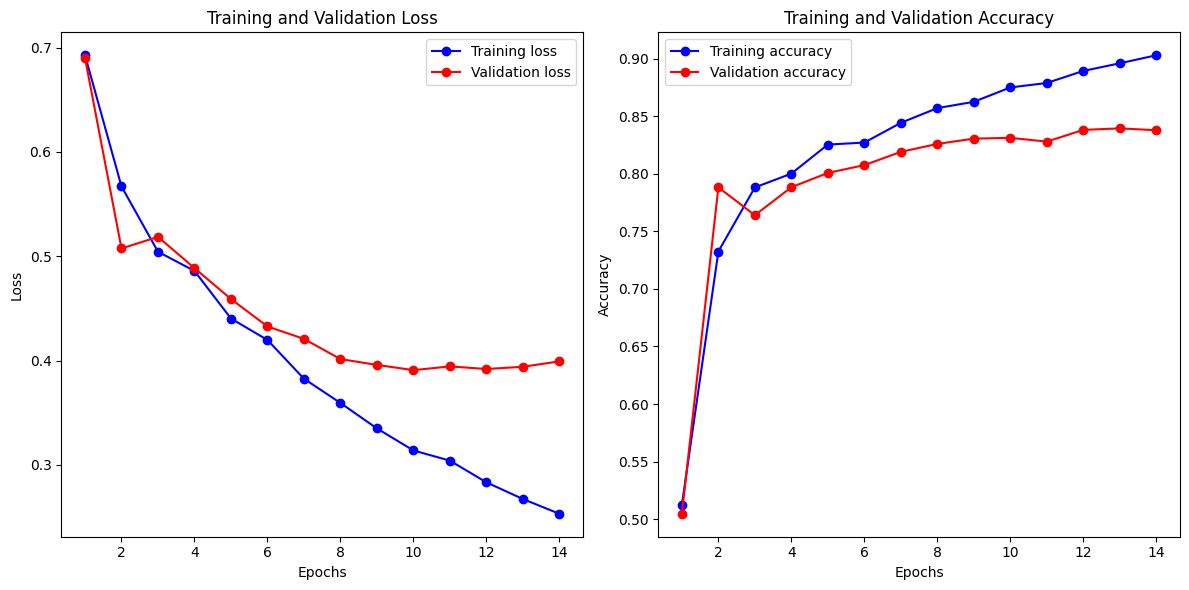

In [15]:
import matplotlib.pyplot as plt
# Lấy thông tin lịch sử huấn luyện
history_dict = history.history
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(accuracy) + 1)

# Vẽ đồ thị cho Training và Validation Loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo-', label='Training loss')  # Đường màu xanh
plt.plot(epochs, val_loss, 'ro-', label='Validation loss')  # Đường màu đỏ
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Vẽ đồ thị cho Training và Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'bo-', label='Training accuracy')  # Đường màu xanh
plt.plot(epochs, val_accuracy, 'ro-', label='Validation accuracy')  # Đường màu đỏ
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Hiển thị đồ thị
plt.tight_layout()
plt.show()

In [16]:
model.save("phan_tich_cam_xuc.keras")


In [ ]:
## **HƯỚNG DẪN SỬ DỤNG**

- **File này (Phân_tích_cảm_xúc.ipynb)**: Dùng để train mô hình từ đầu và lưu model/tokenizer.
- **File Test_Model.ipynb**: Dùng để load model đã train và test với input tùy chỉnh.
- **File Train_Model.ipynb**: Bản sao của file này, dùng riêng cho việc train (để tránh chạy nhầm phần test).

Sau khi train xong, mở file **Test_Model.ipynb** để test mô hình.

